# 01 — Parse quality and dataset coverage

This notebook checks whether `raw_responses.jsonl` has been successfully converted into `parsed_responses.jsonl`.

The GPT interpretation instructions have been revised so that the naïve prompt's `free_text_unparsed` outputs are treated as **expected baseline behaviour**, not parse failures.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

# Robust project-root detection: works when run from notebooks/ or project root.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = DATA_DIR / "outputs"
PARSED_PATH = OUTPUT_DIR / "parsed_responses.jsonl"
RAW_PATH = OUTPUT_DIR / "raw_responses.jsonl"

# Optional .env loading for PyCharm/Jupyter server contexts that do not inherit shell exports.
try:
    from dotenv import load_dotenv
    load_dotenv(PROJECT_ROOT / ".env")
except ImportError:
    pass

def read_jsonl(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} line {line_no}: {exc}") from exc
    return pd.DataFrame(records)

def pct(x):
    if x is None or pd.isna(x):
        return "NA"
    return f"{100 * float(x):.1f}%"

def safe_accuracy(df: pd.DataFrame, pred_col: str, gold_col: str) -> float | None:
    if df.empty or pred_col not in df.columns or gold_col not in df.columns:
        return None
    sub = df[df[pred_col].notna() & df[gold_col].notna()].copy()
    if sub.empty:
        return None
    return float((sub[pred_col].astype(str) == sub[gold_col].astype(str)).mean())

def display_compact_df(df: pd.DataFrame, font_size: str = "10px", max_rows: int = 50):
    """Display a compact DataFrame with smaller notebook font."""
    if df is None:
        display(Markdown("_No DataFrame to display._"))
        return
    with pd.option_context("display.max_rows", max_rows, "display.max_columns", 100, "display.max_colwidth", 100):
        display(
            df.style.set_table_styles([
                {"selector": "th", "props": [
                    ("font-size", font_size),
                    ("padding", "3px 6px"),
                    ("white-space", "nowrap"),
                ]},
                {"selector": "td", "props": [
                    ("font-size", font_size),
                    ("padding", "3px 6px"),
                    ("white-space", "nowrap"),
                ]},
            ])
        )

HTML("""
<style>
.dataframe th, .dataframe td {
    font-size: 10px !important;
    padding: 3px 6px !important;
}
.output_area pre {
    font-size: 11px !important;
}
</style>
""")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print("OPENAI_API_KEY loaded:", bool(os.getenv("OPENAI_API_KEY")))

PROJECT_ROOT = /Users/Shared/image_schema_llm_project
OPENAI_API_KEY loaded: True


In [2]:
# --- Optional GPT interpretation layer ---------------------------------------
# Set this to True when you want notebook cells to call the OpenAI API.
# Leave False for normal reproducible analysis without API calls.
ENABLE_GPT_INTERPRETATION = True

# Use a low-cost/current model available to your OpenAI API project.
# Change this to match the model enabled in your account, e.g. "gpt-5.4-mini".
INTERPRETATION_MODEL = os.getenv("INTERPRETATION_MODEL", "gpt-5.4-mini")

INTERPRETATION_CACHE_PATH = OUTPUT_DIR / "notebook_interpretations.json"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_CONTEXT = """
This is a Computational Linguistics MA project evaluating whether structured
image-schema prompting improves LLM interpretation of literal spatial,
metaphorical spatial, and weak-schema control sentences.

Important parsing convention:
- The naive prompt family is intentionally free-text and should normally appear
  as parse_status == "free_text_unparsed".
- free_text_unparsed is not a parsing failure when prompt_family == "naive".
  It is the expected baseline behaviour for ordinary paraphrase/interpretation.
- Direct-schema and structured-role prompts are the structured JSON-producing
  prompt families.
- Parse quality should be evaluated separately for naive and structured prompts.
- For schema accuracy, use records where usable_for_schema_accuracy == True.
- For literal/metaphorical/control accuracy, use records where usable_for_lm_accuracy == True.
- Partial records may still be valid for selected metrics if the relevant
  usability flag is True.
- The project does not claim that LLMs possess embodied cognition; it tests
  whether image-schema prompting provides a useful intermediate representational
  layer beyond ordinary paraphrase.
"""

def load_interpretation_cache() -> dict:
    if INTERPRETATION_CACHE_PATH.exists():
        try:
            return json.loads(INTERPRETATION_CACHE_PATH.read_text(encoding="utf-8"))
        except json.JSONDecodeError:
            return {}
    return {}

def save_interpretation_cache(cache: dict) -> None:
    INTERPRETATION_CACHE_PATH.write_text(
        json.dumps(cache, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

interpretation_cache = load_interpretation_cache()

def df_to_compact_markdown(df: pd.DataFrame, max_rows: int = 20) -> str:
    if df is None or df.empty:
        return "No rows available."
    compact = df.copy()
    for col in compact.select_dtypes(include="number").columns:
        compact[col] = compact[col].round(4)
    if len(compact) > max_rows:
        compact = compact.head(max_rows)
    return compact.to_markdown(index=False)

def _openai_interpretation_call(prompt: str, model: str = INTERPRETATION_MODEL) -> str:
    try:
        from openai import OpenAI
    except ImportError as exc:
        raise RuntimeError("Install the OpenAI SDK with: python -m pip install openai") from exc

    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("OPENAI_API_KEY is not set. Add it to .env or export it before starting Jupyter.")

    client = OpenAI()
    response = client.responses.create(
        model=model,
        input=prompt,
    )
    return response.output_text

def interpret_result(
    result_df: pd.DataFrame,
    *,
    title: str,
    cache_key: str,
    research_context: str = RESEARCH_CONTEXT,
    max_rows: int = 20,
    force_refresh: bool = False,
) -> str | None:
    """
    Generate or retrieve a concise GPT interpretation for a result table.

    Output requested:
    - 3 to 5 concise bullet points
    - one short summarising paragraph
    - methodological caution where relevant
    """
    if not force_refresh and cache_key in interpretation_cache:
        return interpretation_cache[cache_key]

    if not ENABLE_GPT_INTERPRETATION:
        return None

    table_md = df_to_compact_markdown(result_df, max_rows=max_rows)

    prompt = f"""
You are helping interpret results from a Computational Linguistics MA project.

Project context:
{research_context}

Result title:
{title}

Results table:
{table_md}

Critical interpretation rules:
- Do not treat naive prompt free-text outputs as parse failures.
- If parse_status == "free_text_unparsed" occurs for prompt_family == "naive",
  describe this as expected baseline behaviour.
- Evaluate JSON conformity mainly for direct_schema and structured_role_based prompts.
- Distinguish raw-data quality, parsing coverage, and semantic accuracy.
- Do not overclaim embodied cognition in LLMs.
- If a table includes both all-prompt and structured-only parse results, explain
  why structured-only results are the correct basis for JSON parsing quality.
- If partial records are present, mention whether the usability flags still
  permit them to contribute to specific metrics.

Output requirements:
- Use 3 to 5 concise bullet points.
- Then add one short summarising paragraph.
- Mention any important methodological caution.
- Prefer precise wording such as "suggests", "indicates", "is consistent with".
- Keep the whole answer under 180 words.
"""
    text = _openai_interpretation_call(prompt)
    interpretation_cache[cache_key] = text
    save_interpretation_cache(interpretation_cache)
    return text

def display_gpt_interpretation(
    result_df: pd.DataFrame,
    *,
    title: str,
    cache_key: str,
    max_rows: int = 20,
    force_refresh: bool = False,
):
    """
    Display GPT interpretation below a result cell.
    If API calls are disabled and no cached interpretation exists, display a placeholder.
    """
    text = interpret_result(
        result_df,
        title=title,
        cache_key=cache_key,
        max_rows=max_rows,
        force_refresh=force_refresh,
    )

    if text is None:
        display(Markdown(
            f"### GPT interpretation: {title}\n\n"
            "_Disabled. Set `ENABLE_GPT_INTERPRETATION = True` and rerun this cell to generate concise bullet points and a summary paragraph._"
        ))
        return None

    display(Markdown(f"### GPT interpretation: {title}\n\n{text}"))
    return text

## Load parsed responses

In [3]:
parsed = read_jsonl(PARSED_PATH)
print(f"Parsed records: {len(parsed)}")
display_compact_df(parsed.head())

Parsed records: 5400


,run_key,run_index,provider,model_id,model_name,prompt_id,prompt_family,prompt_version,condition_id,condition_family,temperature,top_p,sentence_id,sentence_type,expected_schema_primary,expected_literal_or_metaphorical,repetition_index,raw_response_status,provider_response_id,input_tokens,output_tokens,parse_status,parse_error,parser_strategy,parse_quality,usable_for_schema_accuracy,usable_for_lm_accuracy,literal_or_metaphorical,main_image_schema,secondary_image_schemas,trajector,landmark_or_container,source,path,goal,obstacle,force,source_domain,target_domain,interpretation,schema_explanation,confidence,parsed_json
0,gemini_2_5_flash|p_naive_v1|c_temp_0_v1|s0001|0,3600,google,gemini_2_5_flash,gemini-2.5-flash,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,0.000000,1.000000,s0001,literal_spatial,CONTAINER,literal,0,success,s6YRaqGfCLOD7M8P6aryYA,56,9,free_text_unparsed,nan,free_text_passthrough,free_text,False,False,nan,nan,[],,,,,,,,[],[],The keys are physically located inside the box.,,nan,{}
1,gemini_2_5_flash|p_naive_v1|c_temp_0_v1|s0002|0,3601,google,gemini_2_5_flash,gemini-2.5-flash,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,0.000000,1.000000,s0002,literal_spatial,CONTAINER,literal,0,success,tKYRaqOpEdiOxN8P9-nB2QQ,56,22,free_text_unparsed,nan,free_text_passthrough,free_text,False,False,nan,nan,[],,,,,,,,[],[],"A young person entered a tent by moving their body, likely using their hands and feet, to get inside.",,nan,{}
2,gemini_2_5_flash|p_naive_v1|c_temp_0_v1|s0003|0,3602,google,gemini_2_5_flash,gemini-2.5-flash,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,0.000000,1.000000,s0003,literal_spatial,CONTAINER,literal,0,success,taYRapuZKqX2xs0PqYfIgAM,56,9,free_text_unparsed,nan,free_text_passthrough,free_text,False,False,nan,nan,[],,,,,,,,[],[],The letter was physically enclosed within the envelope.,,nan,{}
3,gemini_2_5_flash|p_naive_v1|c_temp_0_v1|s0004|0,3603,google,gemini_2_5_flash,gemini-2.5-flash,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,0.000000,1.000000,s0004,literal_spatial,CONTAINER,literal,0,success,t6YRao3fIaWakdUPr_f1yQI,56,15,free_text_unparsed,nan,free_text_passthrough,free_text,False,False,nan,nan,[],,,,,,,,[],[],The soup remained inside the bowl; it was not spilled or poured out.,,nan,{}
4,gemini_2_5_flash|p_naive_v1|c_temp_0_v1|s0005|0,3604,google,gemini_2_5_flash,gemini-2.5-flash,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,0.000000,1.000000,s0005,literal_spatial,CONTAINER,literal,0,success,uKYRaueBHZ60kdUPw_PW0AI,57,16,free_text_unparsed,nan,free_text_passthrough,free_text,False,False,nan,nan,[],,,,,,,,[],[],An avian creature moved through the air from inside an enclosed structure to the outside.,,nan,{}


## Overall parse status distribution

In [4]:
parse_counts = (
    parsed["parse_status"]
    .value_counts(dropna=False)
    .rename_axis("parse_status")
    .reset_index(name="count")
)
parse_counts["percent"] = parse_counts["count"] / parse_counts["count"].sum()
display_compact_df(parse_counts)
display_gpt_interpretation(
    parse_counts,
    title="Overall parse status distribution",
    cache_key="v2_01_overall_parse_status_distribution",
)

,parse_status,count,percent
0,parsed,3569,0.660926
1,free_text_unparsed,1800,0.333333
2,partial,31,0.005741


### GPT interpretation: Overall parse status distribution

- Overall, 66.09% of outputs were `parsed`, 33.33% were `free_text_unparsed`, and 0.57% were `partial`.
- The `free_text_unparsed` share is not inherently a failure: for the naive prompt family, free-text interpretation is the expected baseline behaviour.
- Because the naive condition is intentionally non-JSON, JSON parsing quality should be assessed mainly on the structured prompt families (`direct_schema` and `structured_role_based`), not on the all-prompt aggregate.
- The small number of `partial` records indicates limited parsing irregularity; these records may still contribute to schema or literal/metaphorical/control accuracy if the relevant usability flag is `True`.
- This table reflects parsing coverage and output format conformity, not semantic accuracy or evidence of embodied cognition.

In short, the aggregate distribution is consistent with the experimental design: naive prompts produce ordinary free-text responses, while structured prompts are the appropriate basis for evaluating JSON conformity. A key methodological caution is to separate raw parse status from downstream semantic accuracy, using the designated usability flags for each metric.

'- Overall, 66.09% of outputs were `parsed`, 33.33% were `free_text_unparsed`, and 0.57% were `partial`.\n- The `free_text_unparsed` share is not inherently a failure: for the naive prompt family, free-text interpretation is the expected baseline behaviour.\n- Because the naive condition is intentionally non-JSON, JSON parsing quality should be assessed mainly on the structured prompt families (`direct_schema` and `structured_role_based`), not on the all-prompt aggregate.\n- The small number of `partial` records indicates limited parsing irregularity; these records may still contribute to schema or literal/metaphorical/control accuracy if the relevant usability flag is `True`.\n- This table reflects parsing coverage and output format conformity, not semantic accuracy or evidence of embodied cognition.\n\nIn short, the aggregate distribution is consistent with the experimental design: naive prompts produce ordinary free-text responses, while structured prompts are the appropriate basis 

## Naïve baseline parse status

In [5]:
naive_parsed = parsed[parsed["prompt_family"] == "naive"].copy()

naive_parse_counts = (
    naive_parsed["parse_status"]
    .value_counts(dropna=False)
    .rename_axis("parse_status")
    .reset_index(name="count")
)
naive_parse_counts["percent"] = naive_parse_counts["count"] / naive_parse_counts["count"].sum()

display_compact_df(naive_parse_counts)
display_gpt_interpretation(
    naive_parse_counts,
    title="Naive baseline parse status",
    cache_key="v2_01_naive_baseline_parse_status",
)

,parse_status,count,percent
0,free_text_unparsed,1800,1.000000


### GPT interpretation: Naive baseline parse status

- The table shows that all 1,800 naive-baseline outputs have `parse_status == "free_text_unparsed"`; the reported percent value of `1` appears to indicate 100% as a proportion.

- This is expected baseline behaviour for the naive prompt family, not a parsing failure. The naive condition is intentionally free-text paraphrase/interpretation rather than JSON output.

- This result therefore says little about JSON parsing quality. JSON conformity should be assessed on the structured prompt families: `direct_schema` and `structured_role_based`.

- Methodologically, this table should be interpreted as raw parse-status coverage for the naive baseline only, not as evidence of poor data quality or low semantic accuracy.

- Accuracy analyses should use the relevant usability flags: `usable_for_schema_accuracy` for schema accuracy and `usable_for_lm_accuracy` for literal/metaphorical/control accuracy.

In sum, the result is consistent with the experimental design: naive prompts produce ordinary unparsed free text. The main caution is not to conflate expected free-text baseline behaviour with structured-output parsing failure or with the model’s interpretive accuracy.

'- The table shows that all 1,800 naive-baseline outputs have `parse_status == "free_text_unparsed"`; the reported percent value of `1` appears to indicate 100% as a proportion.\n\n- This is expected baseline behaviour for the naive prompt family, not a parsing failure. The naive condition is intentionally free-text paraphrase/interpretation rather than JSON output.\n\n- This result therefore says little about JSON parsing quality. JSON conformity should be assessed on the structured prompt families: `direct_schema` and `structured_role_based`.\n\n- Methodologically, this table should be interpreted as raw parse-status coverage for the naive baseline only, not as evidence of poor data quality or low semantic accuracy.\n\n- Accuracy analyses should use the relevant usability flags: `usable_for_schema_accuracy` for schema accuracy and `usable_for_lm_accuracy` for literal/metaphorical/control accuracy.\n\nIn sum, the result is consistent with the experimental design: naive prompts produce

## Structured prompt parse status only

In [6]:
structured_parsed = parsed[parsed["prompt_family"] != "naive"].copy()

structured_parse_counts = (
    structured_parsed["parse_status"]
    .value_counts(dropna=False)
    .rename_axis("parse_status")
    .reset_index(name="count")
)
structured_parse_counts["percent"] = (
    structured_parse_counts["count"] / structured_parse_counts["count"].sum()
)

display_compact_df(structured_parse_counts)
display_gpt_interpretation(
    structured_parse_counts,
    title="Structured prompt parse status only",
    cache_key="v2_01_structured_prompt_parse_status_only",
)

,parse_status,count,percent
0,parsed,3569,0.991389
1,partial,31,0.008611


### GPT interpretation: Structured prompt parse status only

- The structured JSON-producing prompt families show very high parsing coverage: 3,569 outputs parsed fully, representing 99.14% of structured prompt responses.

- Only 31 outputs, or 0.86%, were partial, indicating a small amount of raw-format imperfection rather than a major parsing problem.

- Because this table is “structured prompt parse status only,” it is the appropriate basis for assessing JSON conformity; naive free-text outputs should not be counted as parse failures.

- Partial records should not be discarded automatically: they may still contribute to schema or literal/metaphorical/control accuracy if the relevant usability flag is `True`.

- This result speaks to output-format reliability, not semantic correctness; schema accuracy and literal/metaphorical/control interpretation need to be evaluated separately.

Overall, the table suggests that direct-schema and structured-role prompting produced highly parseable structured outputs, supporting reliable downstream analysis. A key methodological caution is that parsing success should not be conflated with correct interpretation, nor with any claim that the model possesses embodied cognition.

'- The structured JSON-producing prompt families show very high parsing coverage: 3,569 outputs parsed fully, representing 99.14% of structured prompt responses.\n\n- Only 31 outputs, or 0.86%, were partial, indicating a small amount of raw-format imperfection rather than a major parsing problem.\n\n- Because this table is “structured prompt parse status only,” it is the appropriate basis for assessing JSON conformity; naive free-text outputs should not be counted as parse failures.\n\n- Partial records should not be discarded automatically: they may still contribute to schema or literal/metaphorical/control accuracy if the relevant usability flag is `True`.\n\n- This result speaks to output-format reliability, not semantic correctness; schema accuracy and literal/metaphorical/control interpretation need to be evaluated separately.\n\nOverall, the table suggests that direct-schema and structured-role prompting produced highly parseable structured outputs, supporting reliable downstream

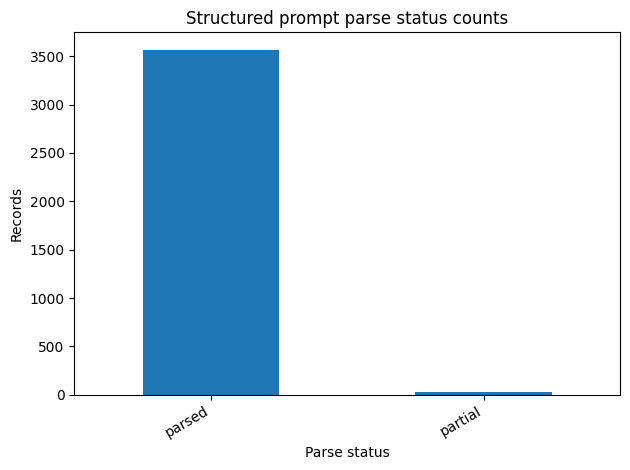

In [7]:
ax = structured_parse_counts.plot(kind="bar", x="parse_status", y="count", legend=False)
ax.set_title("Structured prompt parse status counts")
ax.set_xlabel("Parse status")
ax.set_ylabel("Records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Parse status by prompt family

In [8]:
parse_by_prompt = pd.crosstab(
    parsed["prompt_family"],
    parsed["parse_status"],
    margins=True
).reset_index()
display_compact_df(parse_by_prompt)
display_gpt_interpretation(
    parse_by_prompt,
    title="Parse status by prompt family",
    cache_key="v2_01_parse_status_by_prompt_family",
)

parse_status,prompt_family,free_text_unparsed,parsed,partial,All
0,direct_schema,0,1769,31,1800
1,naive,1800,0,0,1800
2,structured_role_based,0,1800,0,1800
3,All,1800,3569,31,5400


### GPT interpretation: Parse status by prompt family

- The table shows the expected contrast between prompt families: all 1,800 naive outputs are `free_text_unparsed`, which is appropriate for a free-text baseline and should not be counted as parsing failure.

- JSON conformity should be assessed on the structured prompt families only. Across `direct_schema` and `structured_role_based`, 3,569/3,600 outputs were fully parsed, with 31 partial records and no free-text-unparsed cases.

- `structured_role_based` achieved complete parsing coverage: 1,800/1,800 parsed. `direct_schema` was also highly reliable, with 1,769/1,800 parsed and 31 partial records.

- The partial direct-schema records indicate minor format or completeness issues, but they may still contribute to schema or literal/metaphorical/control accuracy if the relevant usability flag is true.

- Methodologically, parse status reflects output format and extraction quality, not semantic correctness; schema accuracy and literal/metaphorical/control accuracy should be evaluated separately using their respective usability flags.

Overall, the results suggest that structured prompting produced highly reliable machine-readable outputs, especially for the structured-role format. The naive condition functions as an ordinary paraphrase baseline, not a failed JSON condition. These findings support claims about representational utility, but not claims that the model possesses embodied cognition.

'- The table shows the expected contrast between prompt families: all 1,800 naive outputs are `free_text_unparsed`, which is appropriate for a free-text baseline and should not be counted as parsing failure.\n\n- JSON conformity should be assessed on the structured prompt families only. Across `direct_schema` and `structured_role_based`, 3,569/3,600 outputs were fully parsed, with 31 partial records and no free-text-unparsed cases.\n\n- `structured_role_based` achieved complete parsing coverage: 1,800/1,800 parsed. `direct_schema` was also highly reliable, with 1,769/1,800 parsed and 31 partial records.\n\n- The partial direct-schema records indicate minor format or completeness issues, but they may still contribute to schema or literal/metaphorical/control accuracy if the relevant usability flag is true.\n\n- Methodologically, parse status reflects output format and extraction quality, not semantic correctness; schema accuracy and literal/metaphorical/control accuracy should be evalua

## Structured prompt parse quality and recovery strategy

In [9]:
structured_quality_counts = (
    structured_parsed["parse_quality"]
    .value_counts(dropna=False)
    .rename_axis("parse_quality")
    .reset_index(name="count")
)
structured_quality_counts["percent"] = structured_quality_counts["count"] / structured_quality_counts["count"].sum()

display_compact_df(structured_quality_counts)
display_gpt_interpretation(
    structured_quality_counts,
    title="Structured prompt parse quality distribution",
    cache_key="v2_01_structured_parse_quality_distribution",
)

,parse_quality,count,percent
0,strict_complete,3407,0.946389
1,partial_core_fields,162,0.045000
2,partial_literality_only,31,0.008611


### GPT interpretation: Structured prompt parse quality distribution

- For the structured JSON-producing prompt families, parse quality is very high: 3,407/3,600 outputs are `strict_complete` (94.64%).
- A further 162 outputs (4.50%) have `partial_core_fields`, indicating that key fields were recoverable even if the full structured format was incomplete.
- Only 31 outputs (0.86%) are `partial_literality_only`, suggesting limited cases where parsing recovered little beyond the literal/metaphorical/control label.
- These figures should be interpreted as structured-prompt JSON conformity, not as an all-prompt parsing result: naive free-text outputs should normally be `free_text_unparsed` and are expected baseline behaviour, not parse failures.
- Partial records may still contribute to schema or literal/metaphorical/control accuracy where the relevant usability flag is `True`.

Overall, the distribution indicates strong parsing coverage for the direct-schema and structured-role prompt families, supporting their use for downstream structured analysis. Methodologically, this should be kept separate from semantic accuracy: well-formed JSON does not by itself show correct schema interpretation, nor does it imply embodied cognition in the model.

'- For the structured JSON-producing prompt families, parse quality is very high: 3,407/3,600 outputs are `strict_complete` (94.64%).\n- A further 162 outputs (4.50%) have `partial_core_fields`, indicating that key fields were recoverable even if the full structured format was incomplete.\n- Only 31 outputs (0.86%) are `partial_literality_only`, suggesting limited cases where parsing recovered little beyond the literal/metaphorical/control label.\n- These figures should be interpreted as structured-prompt JSON conformity, not as an all-prompt parsing result: naive free-text outputs should normally be `free_text_unparsed` and are expected baseline behaviour, not parse failures.\n- Partial records may still contribute to schema or literal/metaphorical/control accuracy where the relevant usability flag is `True`.\n\nOverall, the distribution indicates strong parsing coverage for the direct-schema and structured-role prompt families, supporting their use for downstream structured analysis.

In [10]:
structured_strategy_counts = (
    structured_parsed["parser_strategy"]
    .value_counts(dropna=False)
    .rename_axis("parser_strategy")
    .reset_index(name="count")
)
structured_strategy_counts["percent"] = structured_strategy_counts["count"] / structured_strategy_counts["count"].sum()

display_compact_df(structured_strategy_counts)
display_gpt_interpretation(
    structured_strategy_counts,
    title="Structured prompt parser strategy distribution",
    cache_key="v2_01_structured_parser_strategy_distribution",
)

,parser_strategy,count,percent
0,json_decoder_raw_decode,3407,0.946389
1,partial_key_value_recovery,193,0.053611


### GPT interpretation: Structured prompt parser strategy distribution

- For structured JSON-producing prompts, most outputs were parsed directly: 3,407/3,600 cases, or 94.64%, used `json_decoder_raw_decode`.
- A smaller share, 193/3,600 cases, or 5.36%, required `partial_key_value_recovery`, indicating limited format repair rather than wholesale parsing failure.
- This distribution suggests strong JSON conformity for the structured prompt families, but parse strategy alone does not establish schema, literal/metaphorical, or control accuracy.
- Naive prompt outputs should not be included as JSON failures: `free_text_unparsed` is expected baseline behaviour for ordinary free-text interpretation.
- Any partially recovered records should be evaluated metric-by-metric using the relevant usability flags, e.g. `usable_for_schema_accuracy` or `usable_for_lm_accuracy`.

Overall, the results are consistent with good structured-output compliance for direct-schema and structured-role prompts. The key methodological caution is to separate raw parser success, recoverability, and semantic correctness, and not to interpret improved structured prompting as evidence that the model possesses embodied cognition.

'- For structured JSON-producing prompts, most outputs were parsed directly: 3,407/3,600 cases, or 94.64%, used `json_decoder_raw_decode`.\n- A smaller share, 193/3,600 cases, or 5.36%, required `partial_key_value_recovery`, indicating limited format repair rather than wholesale parsing failure.\n- This distribution suggests strong JSON conformity for the structured prompt families, but parse strategy alone does not establish schema, literal/metaphorical, or control accuracy.\n- Naive prompt outputs should not be included as JSON failures: `free_text_unparsed` is expected baseline behaviour for ordinary free-text interpretation.\n- Any partially recovered records should be evaluated metric-by-metric using the relevant usability flags, e.g. `usable_for_schema_accuracy` or `usable_for_lm_accuracy`.\n\nOverall, the results are consistent with good structured-output compliance for direct-schema and structured-role prompts. The key methodological caution is to separate raw parser success, r

## Usability coverage for analysis metrics

In [11]:
coverage = pd.DataFrame([
    {
        "metric": "primary_schema_accuracy",
        "usable_records": int(parsed["usable_for_schema_accuracy"].fillna(False).sum()),
        "total_records": len(parsed),
        "coverage_all_records": parsed["usable_for_schema_accuracy"].fillna(False).mean(),
        "structured_records": int((parsed["prompt_family"] != "naive").sum()),
        "coverage_structured_records": (
            parsed.loc[parsed["prompt_family"] != "naive", "usable_for_schema_accuracy"]
            .fillna(False).mean()
        ),
    },
    {
        "metric": "literal_metaphorical_accuracy",
        "usable_records": int(parsed["usable_for_lm_accuracy"].fillna(False).sum()),
        "total_records": len(parsed),
        "coverage_all_records": parsed["usable_for_lm_accuracy"].fillna(False).mean(),
        "structured_records": int((parsed["prompt_family"] != "naive").sum()),
        "coverage_structured_records": (
            parsed.loc[parsed["prompt_family"] != "naive", "usable_for_lm_accuracy"]
            .fillna(False).mean()
        ),
    },
])
display_compact_df(coverage)
display_gpt_interpretation(
    coverage,
    title="Usability coverage for analysis metrics",
    cache_key="v2_01_usability_coverage",
)

,metric,usable_records,total_records,coverage_all_records,structured_records,coverage_structured_records
0,primary_schema_accuracy,3569,5400,0.660926,3600,0.991389
1,literal_metaphorical_accuracy,3600,5400,0.666667,3600,1.000000


### GPT interpretation: Usability coverage for analysis metrics

- Overall usability is about two thirds of all 5,400 records because the naive prompt family is free-text by design and normally appears as `free_text_unparsed`; this is expected baseline behaviour, not a parsing failure.

- For structured JSON-producing prompts, coverage is very high: primary schema accuracy is usable for 3,569/3,600 structured records, or 99.14%.

- Literal/metaphorical/control accuracy has full structured coverage: 3,600/3,600 structured records are usable, indicating complete availability for that metric within the structured prompt families.

- JSON conformity should therefore be assessed mainly on the direct-schema and structured-role prompts, not on the all-prompt coverage figure, which is lowered by the intentionally unparsed naive baseline.

- Any partial records should be included only where the relevant usability flag permits it; coverage here indicates metric usability, not necessarily semantic correctness.

In summary, the table suggests strong parsing and metric coverage for the structured prompt families, while the lower all-record coverage mainly reflects the methodological design of including a free-text naive baseline. A key caution is to distinguish raw parse usability from actual schema or literal/metaphorical accuracy, and not to overclaim this as evidence of embodied cognition.

'- Overall usability is about two thirds of all 5,400 records because the naive prompt family is free-text by design and normally appears as `free_text_unparsed`; this is expected baseline behaviour, not a parsing failure.\n\n- For structured JSON-producing prompts, coverage is very high: primary schema accuracy is usable for 3,569/3,600 structured records, or 99.14%.\n\n- Literal/metaphorical/control accuracy has full structured coverage: 3,600/3,600 structured records are usable, indicating complete availability for that metric within the structured prompt families.\n\n- JSON conformity should therefore be assessed mainly on the direct-schema and structured-role prompts, not on the all-prompt coverage figure, which is lowered by the intentionally unparsed naive baseline.\n\n- Any partial records should be included only where the relevant usability flag permits it; coverage here indicates metric usability, not necessarily semantic correctness.\n\nIn summary, the table suggests strong 